In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


%matplotlib widget

# Loading in the iEEG data with memory mapping (no RAM until accessed)

In [2]:
# specify the number of tetrdoes and channels (4 tetrodes with 4 channels each)
nChannels = 16
nTetrodes = 4

# specify the sampling rate (32768 Hz)
sampling_rate = 32768

# specify the amplification factor (1000)
amplification_factor = 1000

# raw data file path
data_path = r'Z:\Buzsakilabspace\LabShare\PaleologosN\iEEG\SpikeSorting_iEEG\NY954_Session20250131_093934\NY954_Session20250131_093934.dat'

# specify the start and end times for the data to be loaded (in seconds)
start_time = 0
end_time = -1

# load the data
data = np.memmap(data_path, dtype=np.int16, mode='r')

# reshape the data to have channels as rows and time points as columns
data = data.reshape(-1, nChannels).T

# Remove the data before the start and end times specified 
start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)
data = data[:, start_sample:end_sample]

# print the shape of the data to verify
print(data.shape)


(16, 471826144)


## Plotting the raw data

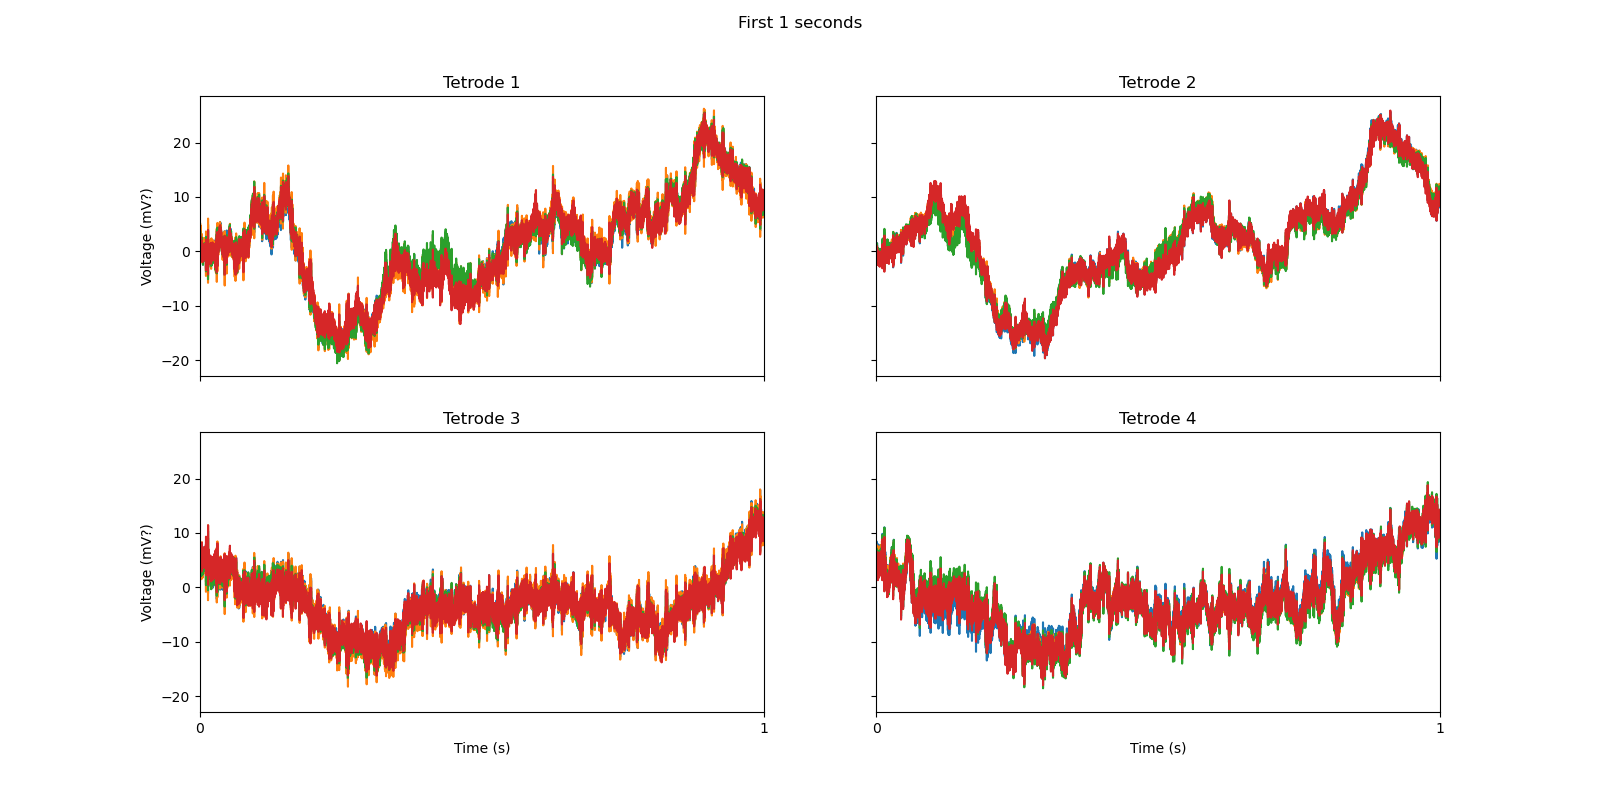

In [3]:
# plot the first 10 seconds of data for the first channel
plot_seconds = 1
fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex=True, sharey=True)
for tetrode_idx in range(nTetrodes):
    ax = axs[tetrode_idx // 2, tetrode_idx % 2]
    for ch_idx in range(4):
        channel_idx = tetrode_idx * 4 + ch_idx
        ax.plot(data[channel_idx, :sampling_rate * plot_seconds] / amplification_factor)

# set x axis in seconds
for ax in axs.flat:
    ax.set_xlim(0, sampling_rate * plot_seconds)
    ax.set_xticks(np.arange(0, sampling_rate * plot_seconds + 1, sampling_rate))
    ax.set_xticklabels(np.arange(0, plot_seconds + 1, 1))

plt.suptitle(f'First {plot_seconds} seconds')
axs[0, 0].set_title('Tetrode 1')
axs[0, 1].set_title('Tetrode 2')
axs[1, 0].set_title('Tetrode 3')
axs[1, 1].set_title('Tetrode 4')

# plot y label
axs[0,0].set_ylabel('Voltage (mV?)')
axs[1,0].set_ylabel('Voltage (mV?)')

# plot x label
axs[1,0].set_xlabel('Time (s)')
axs[1,1].set_xlabel('Time (s)')

plt.show()

## high pass filter the data for spike detection
Working 1 tetrode at a time to minimize memory. This can be paralelized across tetrodes 

In [ ]:
# high pass filtering the data at 600 Hz using a Butterworth filter
from scipy.signal import butter, sosfiltfilt
from scipy.stats import zscore

sos = butter(4, [300, 3000], btype='bandpass', fs=sampling_rate, output='sos')

high_pass_data = sosfiltfilt(sos, data, axis=1)

# common median referencing within each tetrode, then z-scoring the data across time points for each channel independently
unrefrenced_mua_data = zscore(high_pass_data, axis=1)
for tetrode in range(nTetrodes):
    print(f'Processing tetrode {tetrode + 1}...')
    tetrode_channels = slice(tetrode * 4, (tetrode + 1) * 4)
    tetrode_data = high_pass_data[tetrode_channels, :]
    median_reference = np.median(tetrode_data, axis=0)
    high_pass_data[tetrode_channels, :] -= median_reference

mua_data = zscore(high_pass_data, axis=1)

In [ ]:
# getting a box car average of the mua averaged across channels in a tetrode
boxcar_avg_data = []
for tetrode in range(nTetrodes):
    tetrode_mua = np.mean(np.abs(mua_data[tetrode * 4:(tetrode + 1) * 4, :]), axis=0)
    window_size = int(0.005 * sampling_rate)  # 5 ms window
    boxcar_avg = zscore(np.convolve(tetrode_mua, np.ones(window_size) / window_size, mode='same'))
    boxcar_avg_data.append(boxcar_avg)
    

# plotting the high pass filtered data

In [ ]:
# plot the first 10 seconds of data for the first channel
plot_seconds = 1
fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex=True, sharey=True)
for tetrode_idx in range(nTetrodes):
    ax = axs[tetrode_idx // 2, tetrode_idx % 2]
    for ch_idx in range(4):
        channel_idx = tetrode_idx * 4 + ch_idx
        ax.plot(mua_data[channel_idx, :sampling_rate * plot_seconds])

# set x axis in seconds
for ax in axs.flat:
    #ax.set_xlim(0, sampling_rate * plot_seconds)
    #ax.set_xticks(np.arange(0, sampling_rate * plot_seconds + 1, sampling_rate))
    #ax.set_xticklabels(np.arange(0, plot_seconds + 1, 1))
    ax.set_ylim(-40, 40)

plt.suptitle(f'First {plot_seconds} seconds')
axs[0, 0].set_title('Tetrode 1')
axs[0, 1].set_title('Tetrode 2')
axs[1, 0].set_title('Tetrode 3')
axs[1, 1].set_title('Tetrode 4')

# plot y label
axs[0,0].set_ylabel('Voltage (z)')
axs[1,0].set_ylabel('Voltage (z)')

# plot x label
axs[1,0].set_xlabel('Time (s)')
axs[1,1].set_xlabel('Time (s)')

plt.show()

In [ ]:
# detecting spikes using a simple thresholding method (threshold is in standard deviations)
from scipy.signal import find_peaks

threshold = 5
max_height = 50
min_distance = int(0.001 * sampling_rate)

spike_times = []

for ch in range(nChannels):
    peaks, props = find_peaks(
        -mua_data[ch],
        height=threshold,
        distance=min_distance
    )
    height = props['peak_heights']
    peaks = peaks[height < max_height]

    # exclude peaks where boxcar average is above 3 standard deviations to avoid detecting spikes during periods of high noise
    peaks = [peak for peak in peaks if boxcar_avg_data[ch // 4][peak] < 1]

    spike_times.append(peaks)
print(f'Number of spikes detected on each channel: {[len(spike_times[i]) for i in range(nChannels)]}')

def align_to_tetrode_trough(mua_data, tetrode_idx, spike_time, window=16):
    ch_start = tetrode_idx * 4
    ch_end = ch_start + 4

    lo = max(0, spike_time - window)
    hi = min(mua_data.shape[1], spike_time + window + 1)

    segment = mua_data[ch_start:ch_end, lo:hi]
    flat_min_idx = np.argmin(segment)
    _, local_time_idx = np.unravel_index(flat_min_idx, segment.shape)

    return lo + local_time_idx

# get the spike times for each tetrode by taking the union of the spike times across its 4 channels
tetrode_spike_times = []
for tetrode_idx in range(nTetrodes):
    ch_start = tetrode_idx * 4
    ch_end = ch_start + 4

    # get the spike times for the 4 channels of the tetrode
    tetrode_channel_spike_times = spike_times[ch_start:ch_end]

    # take the union of the spike times across the 4 channels
    tetrode_spike_time_set = set()
    for ch_spike_times in tetrode_channel_spike_times:
        tetrode_spike_time_set.update(ch_spike_times)

    # align each spike time to the trough of the spike on the tetrode
    aligned_spike_times = []
    for spike_time in sorted(tetrode_spike_time_set):
        aligned_time = align_to_tetrode_trough(mua_data, tetrode_idx, spike_time)
        aligned_spike_times.append(aligned_time)

    tetrode_spike_times.append(np.array(aligned_spike_times))
print(f'Number of spikes detected on each tetrode: {[len(tetrode_spike_times[i]) for i in range(nTetrodes)]}')


In [ ]:
channel_colors = ['blue', 'orange', 'green', 'red']

plot_seconds = 10

# plot the mua_data with the spike times superimposed
fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex=True, sharey=True)
for tetrode_idx in range(4):

    for ch_idx in range(4):
        channel_idx = tetrode_idx * 4 + ch_idx
        axs[tetrode_idx // 2, tetrode_idx % 2].plot(mua_data[channel_idx, :sampling_rate * plot_seconds], channel_colors[ch_idx])
        axs[tetrode_idx // 2, tetrode_idx % 2].scatter(spike_times[channel_idx], mua_data[channel_idx, spike_times[channel_idx]], color='k', s=30)

    # plot the box car average of the mua across the 4 channels of the tetrode in black
    axs[tetrode_idx // 2, tetrode_idx % 2].plot(boxcar_avg_data[tetrode_idx][:sampling_rate * plot_seconds], color='k', linewidth=2, label='Boxcar Avg')

# set x axis in seconds
for ax in axs.flat:
    ax.set_xlim(0, sampling_rate * plot_seconds)
    ax.set_xticks(np.arange(0, sampling_rate * plot_seconds + 1, sampling_rate))
    ax.set_xticklabels(np.arange(0, plot_seconds + 1, 1))

plt.suptitle(f'First {plot_seconds} seconds with detected spikes')
axs[0, 0].set_title('Tetrode 1')
axs[0, 1].set_title('Tetrode 2')
axs[1, 0].set_title('Tetrode 3')
axs[1, 1].set_title('Tetrode 4')
# plot y label
axs[0,0].set_ylabel('Voltage (z)')
axs[1,0].set_ylabel('Voltage (z)')
# plot x label
axs[1,0].set_xlabel('Time (s)')
axs[1,1].set_xlabel('Time (s)')
plt.show()


In [ ]:
# For each tetrode, collect first n_spike spike waveforms on each of its 4 channels
tetrode_waveforms = []
n_spike = -1
for tetrode_idx in range(4):
    spike_times = tetrode_spike_times[tetrode_idx]

    # one list per channel
    channel_waveforms = [[] for _ in range(4)]

    for spike_time in spike_times[:n_spike]:
        if spike_time - 20 >= 0 and spike_time + 20 < mua_data.shape[1]:

            for ch_idx in range(4):
                channel_idx = tetrode_idx * 4 + ch_idx
                waveform = mua_data[channel_idx, spike_time - 20:spike_time + 20]

                channel_waveforms[ch_idx].append(waveform)

    tetrode_waveforms.append(channel_waveforms)

print(len(tetrode_waveforms[0][0]))  # number of valid spikes on tetrode 0, channel 0

channel_colors = ['blue', 'orange', 'green', 'red']

fig, axs = plt.subplots(2, 2, figsize=(16, 16), sharex=True, sharey=True)

for tetrode_idx in range(4):
    ax = axs[tetrode_idx // 2, tetrode_idx % 2]

    for ch_idx in range(4):
        for waveform in tetrode_waveforms[tetrode_idx][ch_idx]:
            ax.plot(waveform, color=channel_colors[ch_idx], alpha=0.2)

    ax.set_title(f'Tetrode {tetrode_idx + 1}')
    ax.set_xlim(0, 40)

    ax.set_xticks([0, 20, 39])
    ax.set_xticklabels([-20, 0, 20])

    ax.set_ylabel('Voltage (z)')
    ax.set_xlabel('Samples around spike')


plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

nClusters = [6, 2, 4, 5]
all_labels = []

fig, axs = plt.subplots(2, 2, figsize=(16, 16))

for i in range(4):
    nSpikes = min(len(tetrode_waveforms[i][j]) for j in range(4))

    X = []

    for k in range(nSpikes):
        spike_features = []

        for j in range(4):
            waveform = tetrode_waveforms[i][j][k]   # shape: (40,)
            spike_features.extend(waveform)

        X.append(spike_features)

    X = np.asarray(X)  # shape: (n_spikes, 4 * 40)

    print(f"Tetrode {i + 1}: {X.shape}")

    if X.shape[0] < nClusters[i]:
        print(f"Skipping tetrode {i + 1}: not enough spikes.")
        continue

    kmeans = KMeans(n_clusters=nClusters[i], random_state=0, n_init="auto")
    labels = kmeans.fit_predict(X)
    all_labels.append(labels)

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X)

    ax = axs[i // 2, i % 2]
    ax.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.3, c=labels)
    ax.set_title(f'Tetrode {i + 1}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

nClusters = [6, 2, 4, 5]


fig, axs = plt.subplots(2, 2, figsize=(16, 16))

for i in range(4):
    nSpikes = min(len(tetrode_waveforms[i][j]) for j in range(4))

    X = []

    for k in range(nSpikes):
        spike_features = []

        for j in range(4):
            waveform = tetrode_waveforms[i][j][k]   # shape: (40,)
            spike_features.extend(waveform)

        X.append(spike_features)

    X = np.asarray(X)  # shape: (n_spikes, 4 * 40)

    print(f"Tetrode {i + 1}: {X.shape}")

    if X.shape[0] < nClusters[i]:
        print(f"Skipping tetrode {i + 1}: not enough spikes.")
        continue

    kmeans = KMeans(n_clusters=nClusters[i], random_state=0, n_init="auto")
    labels = kmeans.fit_predict(X)

    pca = PCA(n_components=3)
    pca_result = pca.fit_transform(X)



    # plot 3d figures color code by cluster labels
    ax = axs[i // 2, i % 2]
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], alpha=0.3, c=all_labels[i])
    ax.set_title(f'Tetrode {i + 1}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
plt.tight_layout()
plt.show()



In [ ]:
# plot the waveforms for each label
for tetrode in range(nTetrodes):
    nlabels = np.max(all_labels[tetrode]) + 1
    fig, axs = plt.subplots(1, nlabels, figsize=(5 * nlabels, 5))
    for label in range(nlabels):
        for ch_idx in range(4):
            channel_idx = tetrode * 4 + ch_idx
            for i, waveform in enumerate(tetrode_waveforms[tetrode][ch_idx]):
                if all_labels[tetrode][i] == label:
                    axs[label].plot(waveform, color=channel_colors[ch_idx], alpha=0.2)
        axs[label].set_title(f'Tetrode {tetrode + 1}, Label {label}')
        axs[label].set_xlim(0, 40)
        axs[label].set_xticks([0, 20, 39])
        axs[label].set_xticklabels([-20, 0, 20])
        axs[label].set_ylabel('Voltage (z)')
        axs[label].set_xlabel('Samples around spike')
    plt.tight_layout()
    plt.show()